In [35]:
# ============================================================
# SMARTINSPECT AI
# Industrial Defect Detection using CNN + Transfer Learning
# ============================================================

import os
import random
import shutil
import zipfile
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from PIL import Image

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)

# Check GPU
gpus = tf.config.list_physical_devices("GPU")

print("\nGPU devices:")
for gpu in gpus:
    print(gpu)

if not gpus:
    raise RuntimeError(
        "GPU NOT FOUND. Go to Runtime > Change runtime type > GPU."
    )

print("\nGPU detected successfully.")

TensorFlow version: 2.20.0

GPU devices:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

GPU detected successfully.


In [36]:
# ============================================================
# CONFIGURATION
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Dataset
DATASET_NAME = "SmartInspect_Final"

# Image size
IMG_SIZE = (260, 260)

# Batch size
BATCH_SIZE = 16

# Number of classes
NUM_CLASSES = 20

# Training
CNN_EPOCHS = 20
TRANSFER_EPOCHS = 15
FINE_TUNE_EPOCHS = 20

print("Configuration")
print("=" * 50)
print("Image size       :", IMG_SIZE)
print("Batch size       :", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)
print("Random seed      :", SEED)

Configuration
Image size       : (260, 260)
Batch size       : 16
Number of classes: 20
Random seed      : 42


In [37]:
# ============================================================
# GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount("/content/drive")

print("Google Drive mounted successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.


In [38]:
# ============================================================
# DATASET ZIP LOCATION
# ============================================================

ZIP_PATH = Path(
    "/content/drive/MyDrive/SmartInspect_AI/SmartInspect_Final.zip"
)

EXTRACT_ROOT = Path("/content")

print("ZIP path:")
print(ZIP_PATH)

print("\nZIP exists:", ZIP_PATH.exists())

if not ZIP_PATH.exists():
    raise FileNotFoundError(
        f"\nDataset ZIP not found:\n{ZIP_PATH}\n\n"
        "Upload SmartInspect_Final.zip to "
        "My Drive/SmartInspect_AI/"
    )

ZIP path:
/content/drive/MyDrive/SmartInspect_AI/SmartInspect_Final.zip

ZIP exists: True


In [39]:
# ============================================================
# EXTRACT DATASET
# ============================================================

EXTRACTED_DIR = Path("/content/SmartInspect_Final")

# Remove old extraction if it exists
if EXTRACTED_DIR.exists():
    shutil.rmtree(EXTRACTED_DIR)

print("Extracting dataset...")

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_ROOT)

print("Extraction complete.")

print("\nDataset directory:")
print(EXTRACTED_DIR)

if not EXTRACTED_DIR.exists():
    raise FileNotFoundError(
        "SmartInspect_Final folder was not created."
    )

Extracting dataset...
Extraction complete.

Dataset directory:
/content/SmartInspect_Final


In [40]:
# ============================================================
# DATASET PATHS
# ============================================================

BASE_DIR = Path("/content/SmartInspect_Final")

TRAIN_DIR = BASE_DIR / "train"
VAL_DIR = BASE_DIR / "validation"
TEST_DIR = BASE_DIR / "test"

print("Train directory     :", TRAIN_DIR)
print("Validation directory:", VAL_DIR)
print("Test directory      :", TEST_DIR)

for path in [TRAIN_DIR, VAL_DIR, TEST_DIR]:

    if not path.exists():
        raise FileNotFoundError(
            f"Missing directory: {path}"
        )

print("\nAll dataset directories found.")

Train directory     : /content/SmartInspect_Final/train
Validation directory: /content/SmartInspect_Final/validation
Test directory      : /content/SmartInspect_Final/test

All dataset directories found.


In [41]:
# ============================================================
# CHECK DATASET STRUCTURE
# ============================================================

for split_name, split_dir in [
    ("TRAIN", TRAIN_DIR),
    ("VALIDATION", VAL_DIR),
    ("TEST", TEST_DIR)
]:

    classes = sorted([
        folder.name
        for folder in split_dir.iterdir()
        if folder.is_dir()
    ])

    print("\n" + "=" * 60)
    print(split_name)
    print("=" * 60)

    print("Number of classes:", len(classes))

    for i, class_name in enumerate(classes):
        print(f"{i:2d} -> {class_name}")


TRAIN
Number of classes: 20
 0 -> BSD_defective
 1 -> BSD_good
 2 -> bottle_defective
 3 -> bottle_good
 4 -> cable_defective
 5 -> cable_good
 6 -> carpet_defective
 7 -> carpet_good
 8 -> grid_defective
 9 -> grid_good
10 -> leather_defective
11 -> leather_good
12 -> metal_nut_defective
13 -> metal_nut_good
14 -> toothbrush_defective
15 -> toothbrush_good
16 -> wood_defective
17 -> wood_good
18 -> zipper_defective
19 -> zipper_good

VALIDATION
Number of classes: 20
 0 -> BSD_defective
 1 -> BSD_good
 2 -> bottle_defective
 3 -> bottle_good
 4 -> cable_defective
 5 -> cable_good
 6 -> carpet_defective
 7 -> carpet_good
 8 -> grid_defective
 9 -> grid_good
10 -> leather_defective
11 -> leather_good
12 -> metal_nut_defective
13 -> metal_nut_good
14 -> toothbrush_defective
15 -> toothbrush_good
16 -> wood_defective
17 -> wood_good
18 -> zipper_defective
19 -> zipper_good

TEST
Number of classes: 20
 0 -> BSD_defective
 1 -> BSD_good
 2 -> bottle_defective
 3 -> bottle_good
 4 -> cable_d

In [42]:
# ============================================================
# VERIFY CLASS CONSISTENCY
# ============================================================

train_classes = sorted([
    folder.name
    for folder in TRAIN_DIR.iterdir()
    if folder.is_dir()
])

val_classes = sorted([
    folder.name
    for folder in VAL_DIR.iterdir()
    if folder.is_dir()
])

test_classes = sorted([
    folder.name
    for folder in TEST_DIR.iterdir()
    if folder.is_dir()
])

assert train_classes == val_classes
assert train_classes == test_classes

assert len(train_classes) == NUM_CLASSES

CLASS_NAMES = train_classes

print("Classes:", len(CLASS_NAMES))
print("\nClass mapping:")

for i, name in enumerate(CLASS_NAMES):
    print(f"{i:2d} -> {name}")

print("\nClass consistency verified successfully.")

Classes: 20

Class mapping:
 0 -> BSD_defective
 1 -> BSD_good
 2 -> bottle_defective
 3 -> bottle_good
 4 -> cable_defective
 5 -> cable_good
 6 -> carpet_defective
 7 -> carpet_good
 8 -> grid_defective
 9 -> grid_good
10 -> leather_defective
11 -> leather_good
12 -> metal_nut_defective
13 -> metal_nut_good
14 -> toothbrush_defective
15 -> toothbrush_good
16 -> wood_defective
17 -> wood_good
18 -> zipper_defective
19 -> zipper_good

Class consistency verified successfully.


In [43]:
# ============================================================
# IMAGE COUNT
# ============================================================

def count_images(folder):

    extensions = {
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp"
    }

    return sum(
        1
        for file in folder.rglob("*")
        if file.is_file()
        and file.suffix.lower() in extensions
    )


train_count = count_images(TRAIN_DIR)
val_count = count_images(VAL_DIR)
test_count = count_images(TEST_DIR)

total_count = (
    train_count +
    val_count +
    test_count
)

print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

print("Training images   :", train_count)
print("Validation images :", val_count)
print("Testing images    :", test_count)
print("Total images      :", total_count)

DATASET SUMMARY
Training images   : 3345
Validation images : 709
Testing images    : 737
Total images      : 4791


In [44]:
# ============================================================
# FINAL BLACK IMAGE CHECK
# ============================================================

def find_black_images(root_dir):

    black_images = []

    extensions = {
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp"
    }

    for class_dir in root_dir.iterdir():

        if not class_dir.is_dir():
            continue

        for image_path in class_dir.iterdir():

            if not image_path.is_file():
                continue

            if image_path.suffix.lower() not in extensions:
                continue

            try:

                with Image.open(image_path) as img:

                    img = img.convert("RGB")
                    arr = np.array(img)

                if arr.max() == 0:

                    black_images.append(
                        str(image_path)
                    )

            except Exception:
                pass

    return black_images


black_train = find_black_images(TRAIN_DIR)
black_val = find_black_images(VAL_DIR)
black_test = find_black_images(TEST_DIR)

total_black = (
    len(black_train) +
    len(black_val) +
    len(black_test)
)

print("Black images in train     :", len(black_train))
print("Black images in validation:", len(black_val))
print("Black images in test      :", len(black_test))
print("--------------------------------")
print("TOTAL BLACK IMAGES        :", total_black)

if total_black != 0:

    raise RuntimeError(
        "Black images detected. Do not train yet."
    )

print("\nDataset quality check PASSED.")
print("Zero completely black images.")

Black images in train     : 0
Black images in validation: 0
Black images in test      : 0
--------------------------------
TOTAL BLACK IMAGES        : 0

Dataset quality check PASSED.
Zero completely black images.


,Class,Images
0,BSD_defective,596
1,BSD_good,253
2,bottle_defective,88
3,bottle_good,160
4,cable_defective,128
5,cable_good,197
6,carpet_defective,124
7,carpet_good,215
8,grid_defective,79
9,grid_good,199


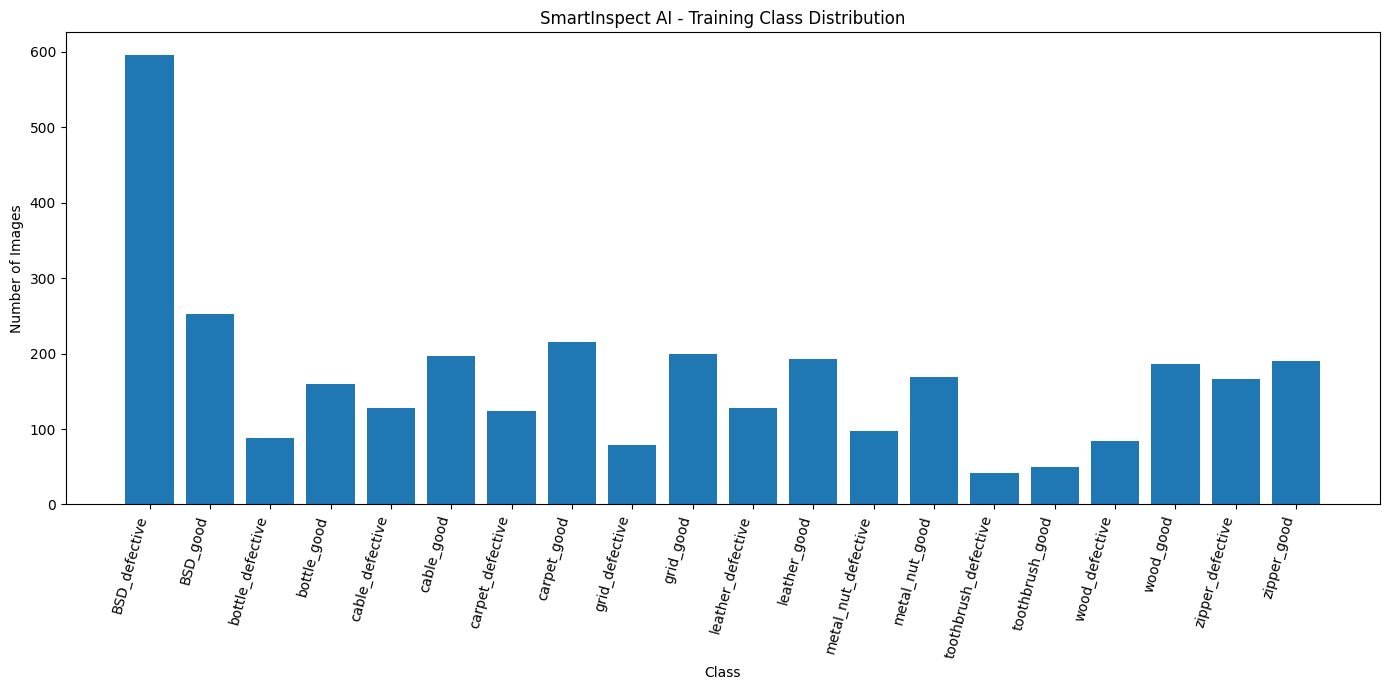

In [45]:
# ============================================================
# CLASS DISTRIBUTION
# ============================================================

train_counts = {}

for class_name in CLASS_NAMES:

    folder = TRAIN_DIR / class_name

    train_counts[class_name] = len([
        file
        for file in folder.iterdir()
        if file.is_file()
    ])


distribution_df = pd.DataFrame(
    {
        "Class": list(train_counts.keys()),
        "Images": list(train_counts.values())
    }
)

display(distribution_df)

plt.figure(figsize=(14, 7))

plt.bar(
    distribution_df["Class"],
    distribution_df["Images"]
)

plt.xticks(
    rotation=75,
    ha="right"
)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("SmartInspect AI - Training Class Distribution")

plt.tight_layout()
plt.show()

In [46]:
# ============================================================
# LOAD DATASETS
# ============================================================

train_ds = tf.keras.utils.image_dataset_from_directory(

    TRAIN_DIR,

    labels="inferred",

    label_mode="categorical",

    class_names=CLASS_NAMES,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=SEED
)


val_ds = tf.keras.utils.image_dataset_from_directory(

    VAL_DIR,

    labels="inferred",

    label_mode="categorical",

    class_names=CLASS_NAMES,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False
)


test_ds = tf.keras.utils.image_dataset_from_directory(

    TEST_DIR,

    labels="inferred",

    label_mode="categorical",

    class_names=CLASS_NAMES,

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False
)

print("\nDatasets loaded successfully.")

Found 3345 files belonging to 20 classes.
Found 709 files belonging to 20 classes.
Found 737 files belonging to 20 classes.

Datasets loaded successfully.


In [47]:
# ============================================================
# PERFORMANCE OPTIMIZATION
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(
    AUTOTUNE
)

val_ds = val_ds.prefetch(
    AUTOTUNE
)

test_ds = test_ds.prefetch(
    AUTOTUNE
)

print("TensorFlow input pipeline optimized.")

TensorFlow input pipeline optimized.


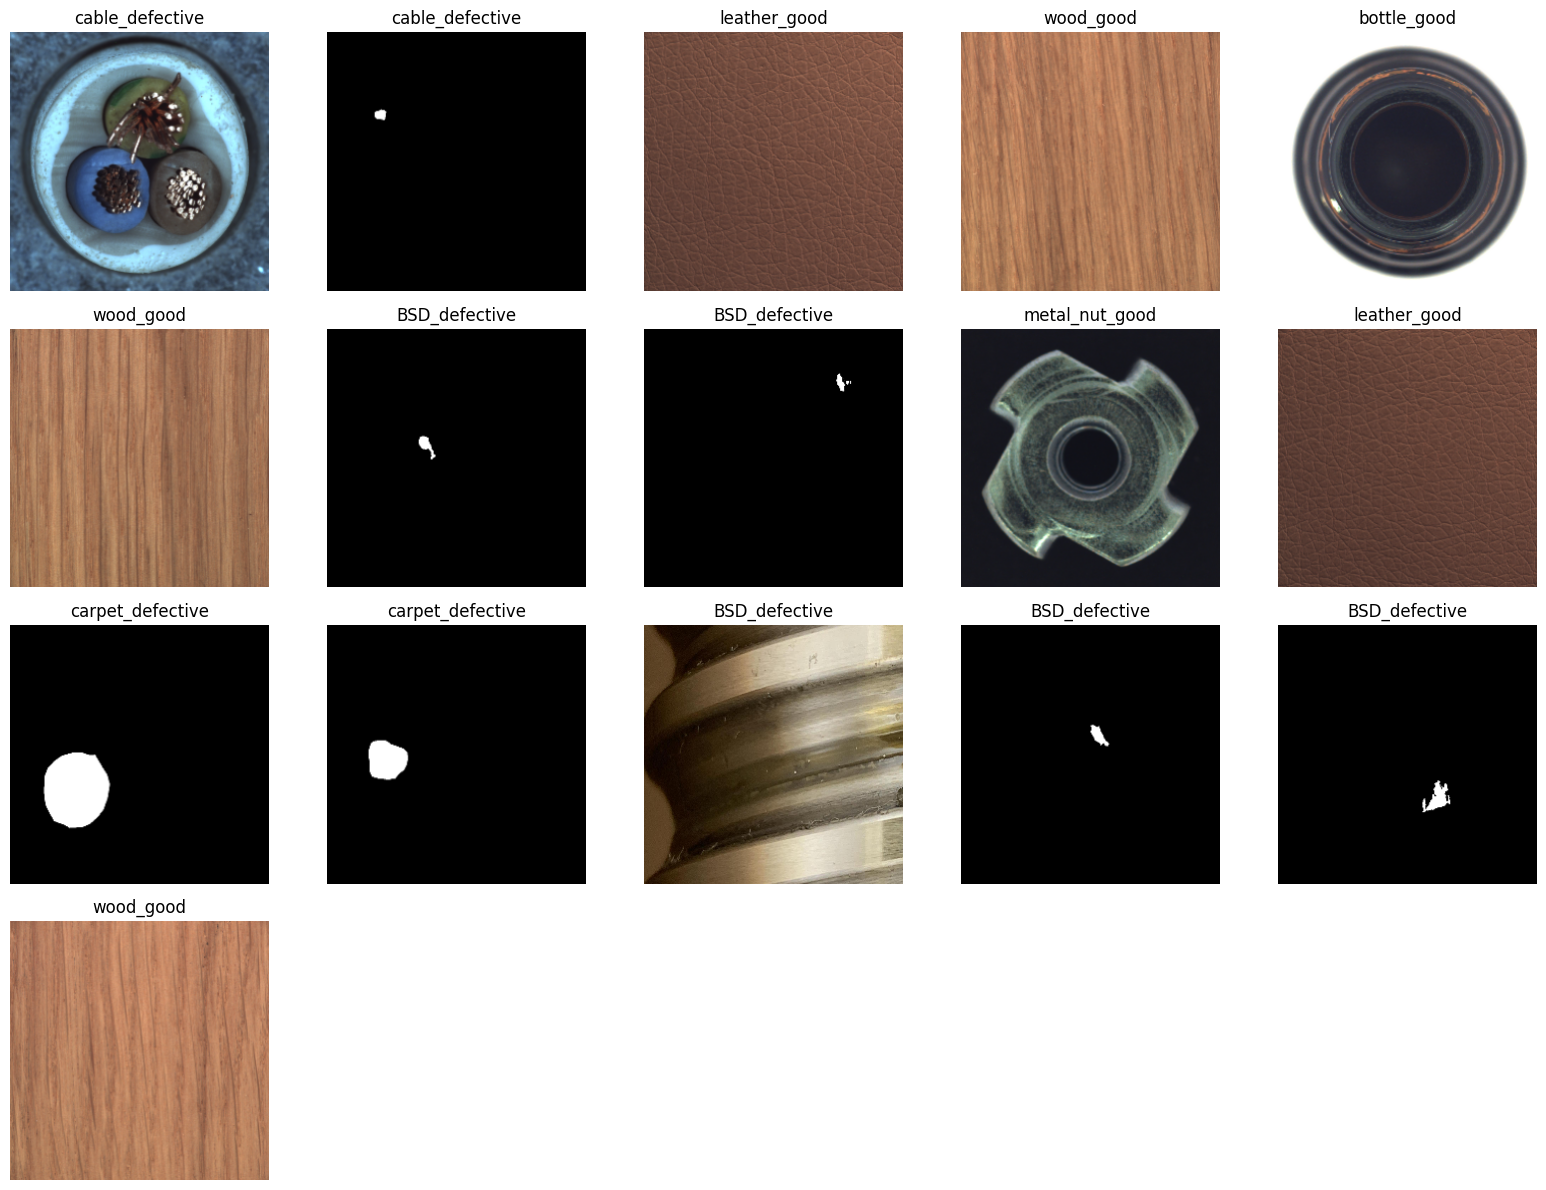

In [48]:
# ============================================================
# VISUALIZE TRAINING DATA
# ============================================================

plt.figure(figsize=(16, 12))

for images, labels in train_ds.take(1):

    for i in range(min(20, len(images))):

        ax = plt.subplot(4, 5, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        label_index = np.argmax(
            labels[i].numpy()
        )

        plt.title(
            CLASS_NAMES[label_index]
        )

        plt.axis("off")

plt.tight_layout()
plt.show()


In [49]:
# ============================================================
# DATA AUGMENTATION
# ============================================================

data_augmentation = keras.Sequential(
    [

        layers.RandomFlip(
            "horizontal"
        ),

        layers.RandomRotation(
            0.05
        ),

        layers.RandomZoom(
            height_factor=0.08,
            width_factor=0.08
        ),

        layers.RandomContrast(
            0.10
        )

    ],
    name="SmartInspect_Augmentation"
)

print(data_augmentation)

<Sequential name=SmartInspect_Augmentation, built=False>


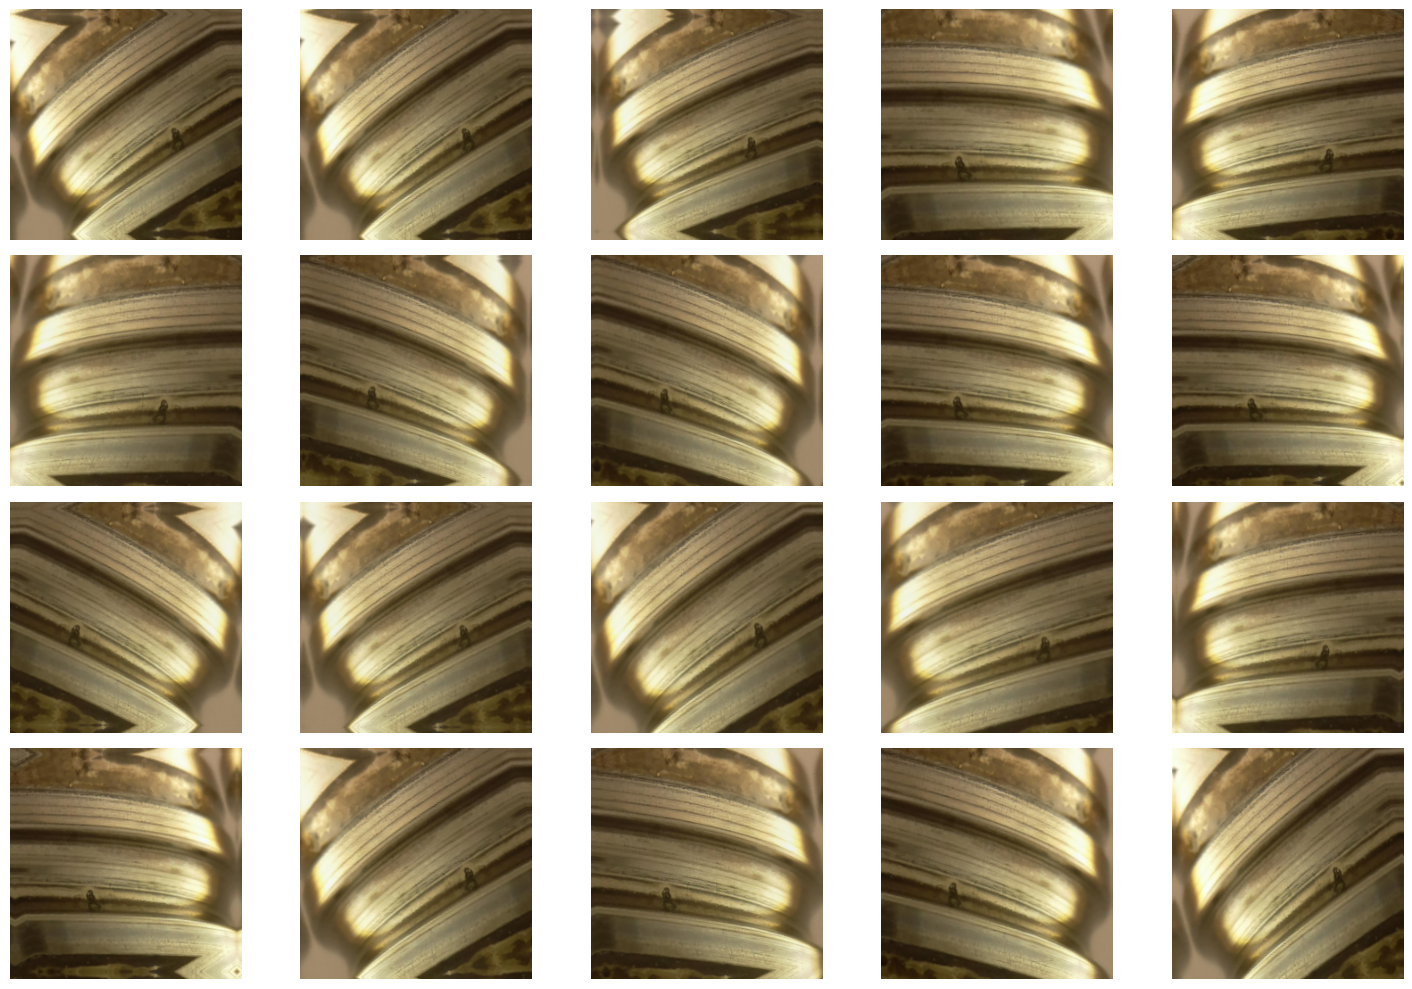

Original class: BSD_defective


In [50]:
# ============================================================
# VISUALIZE AUGMENTATION
# ============================================================

# Find a non-black image from the dataset
sample_image = None
sample_label = None

for images, labels in train_ds.take(5):

    for i in range(len(images)):

        img = images[i]

        if tf.reduce_max(img).numpy() > 0:

            sample_image = tf.expand_dims(
                img,
                axis=0
            )

            sample_label = labels[i]

            break

    if sample_image is not None:
        break


plt.figure(figsize=(15, 10))

for i in range(20):

    augmented = data_augmentation(
        sample_image,
        training=True
    )

    ax = plt.subplot(4, 5, i + 1)

    plt.imshow(
        augmented[0].numpy().astype("uint8")
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

print(
    "Original class:",
    CLASS_NAMES[np.argmax(sample_label.numpy())]
)

In [51]:
# ============================================================
# CLASS WEIGHTS
# ============================================================

y_train = []

for class_index, class_name in enumerate(CLASS_NAMES):

    class_folder = TRAIN_DIR / class_name

    count = len([
        file
        for file in class_folder.iterdir()
        if file.is_file()
    ])

    y_train.extend(
        [class_index] * count
    )

y_train = np.array(y_train)

class_indices = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=class_indices,
    y=y_train
)

CLASS_WEIGHTS = {
    int(index): float(weight)
    for index, weight in zip(
        class_indices,
        weights
    )
}

print("=" * 60)
print("CLASS WEIGHTS")
print("=" * 60)

for index, weight in CLASS_WEIGHTS.items():

    print(
        f"{index:2d} | "
        f"{CLASS_NAMES[index]:25s} | "
        f"{weight:.4f}"
    )

CLASS WEIGHTS
 0 | BSD_defective             | 0.2806
 1 | BSD_good                  | 0.6611
 2 | bottle_defective          | 1.9006
 3 | bottle_good               | 1.0453
 4 | cable_defective           | 1.3066
 5 | cable_good                | 0.8490
 6 | carpet_defective          | 1.3488
 7 | carpet_good               | 0.7779
 8 | grid_defective            | 2.1171
 9 | grid_good                 | 0.8405
10 | leather_defective         | 1.3066
11 | leather_good              | 0.8666
12 | metal_nut_defective       | 1.7066
13 | metal_nut_good            | 0.9896
14 | toothbrush_defective      | 3.9821
15 | toothbrush_good           | 3.3450
16 | wood_defective            | 1.9911
17 | wood_good                 | 0.8992
18 | zipper_defective          | 1.0075
19 | zipper_good               | 0.8803


In [52]:
# ============================================================
# CUSTOM CNN BASELINE
# ============================================================

cnn_model = keras.Sequential(
    [

        keras.Input(
            shape=(
                IMG_SIZE[0],
                IMG_SIZE[1],
                3
            )
        ),

        # Normalize pixels
        layers.Rescaling(
            1.0 / 255
        ),

        # Augmentation
        data_augmentation,

        # Block 1
        layers.Conv2D(
            32,
            3,
            padding="same",
            activation="relu"
        ),

        layers.BatchNormalization(),

        layers.MaxPooling2D(),

        # Block 2
        layers.Conv2D(
            64,
            3,
            padding="same",
            activation="relu"
        ),

        layers.BatchNormalization(),

        layers.MaxPooling2D(),

        # Block 3
        layers.Conv2D(
            128,
            3,
            padding="same",
            activation="relu"
        ),

        layers.BatchNormalization(),

        layers.MaxPooling2D(),

        # Block 4
        layers.Conv2D(
            256,
            3,
            padding="same",
            activation="relu"
        ),

        layers.BatchNormalization(),

        layers.MaxPooling2D(),

        # Classification
        layers.GlobalAveragePooling2D(),

        layers.Dense(
            256,
            activation="relu"
        ),

        layers.Dropout(
            0.40
        ),

        layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    ],

    name="SmartInspect_Custom_CNN"
)

cnn_model.summary()

Model: "SmartInspect_Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ SmartInspect_Augmentation       │ (None, 260, 260, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 260, 260, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 260, 260, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 130, 130, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 130, 130, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 130, 130, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 65, 65, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 65, 65, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 65, 65, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         5,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 461,268 (1.76 MB)

 Trainable params: 460,308 (1.76 MB)

 Non-trainable params: 960 (3.75 KB)

In [53]:
# ============================================================
# COMPILE CNN
# ============================================================

cnn_model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss=keras.losses.CategoricalCrossentropy(
        label_smoothing=0.05
    ),

    metrics=[
        "accuracy"
    ]
)

print("Custom CNN compiled.")

Custom CNN compiled.


In [54]:
# ============================================================
# CNN CALLBACKS
# ============================================================

CNN_MODEL_PATH = (
    "/content/drive/MyDrive/"
    "SmartInspect_AI/"
    "SmartInspect_CustomCNN.keras"
)

cnn_callbacks = [

    keras.callbacks.ModelCheckpoint(
        CNN_MODEL_PATH,

        monitor="val_accuracy",

        mode="max",

        save_best_only=True,

        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.3,

        patience=3,

        min_lr=1e-7,

        verbose=1
    ),

    keras.callbacks.EarlyStopping(

        monitor="val_accuracy",

        patience=6,

        mode="max",

        restore_best_weights=True,

        verbose=1
    )
]

print("CNN callbacks ready.")

CNN callbacks ready.


In [55]:
# ============================================================
# TRAIN CUSTOM CNN
# ============================================================

cnn_history = cnn_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=CNN_EPOCHS,

    class_weight=CLASS_WEIGHTS,

    callbacks=cnn_callbacks
)

Epoch 1/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4175 - loss: 2.1148
Epoch 1: val_accuracy improved from None to 0.15797, saving model to /content/drive/MyDrive/SmartInspect_AI/SmartInspect_CustomCNN.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SmartInspect_AI/SmartInspect_CustomCNN.keras
210/210 ━━━━━━━━━━━━━━━━━━━━ 35s 115ms/step - accuracy: 0.4616 - loss: 1.8460 - val_accuracy: 0.1580 - val_loss: 3.3487 - learning_rate: 0.0010
Epoch 2/20
209/210 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.4861 - loss: 1.5561
Epoch 2: val_accuracy improved from 0.15797 to 0.43300, saving model to /content/drive/MyDrive/SmartInspect_AI/SmartInspect_CustomCNN.keras

Epoch 2: finished saving model to /content/drive/MyDrive/SmartInspect_AI/SmartInspect_CustomCNN.keras
210/210 ━━━━━━━━━━━━━━━━━━━━ 24s 114ms/step - accuracy: 0.5010 - loss: 1.5496 - val_accuracy: 0.4330 - val_loss: 1.6484 - learning_rate: 0.0010
Epoch 3/20
209/210 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step 

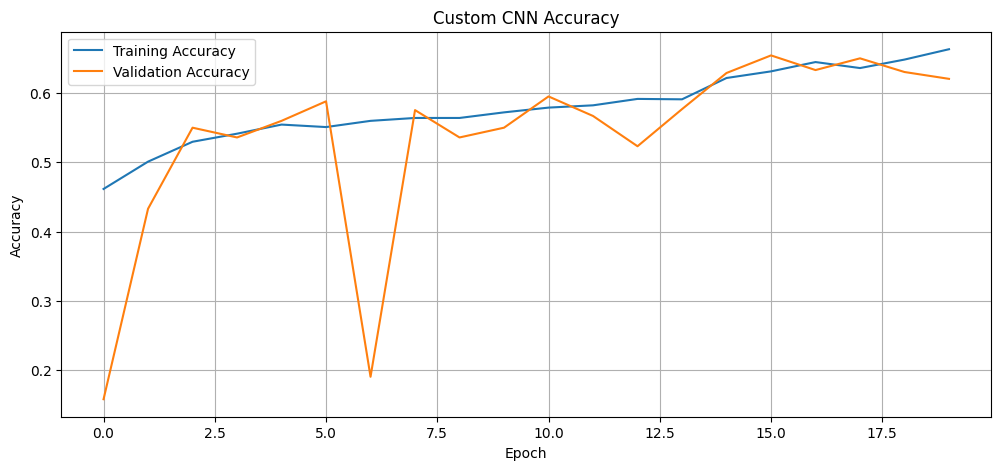

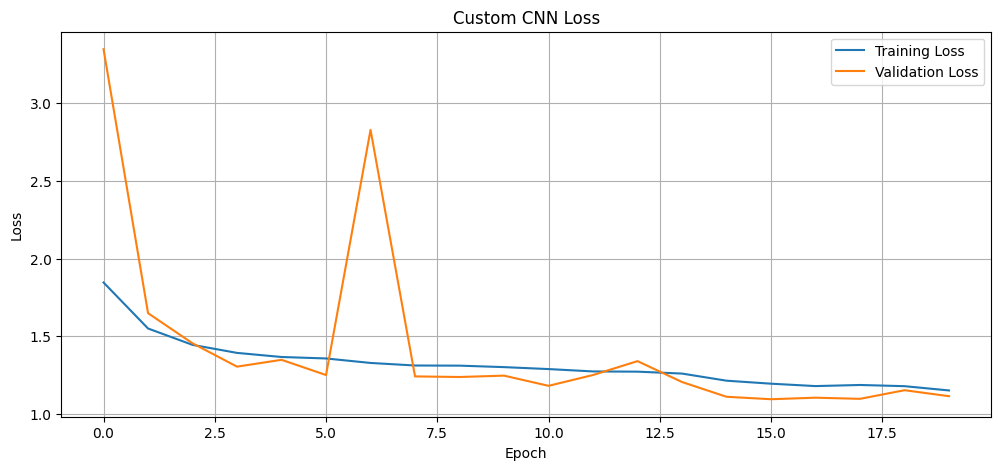

In [56]:
# ============================================================
# CNN TRAINING CURVES
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    cnn_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    cnn_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom CNN Accuracy")

plt.legend()

plt.grid(True)

plt.show()


plt.figure(figsize=(12, 5))

plt.plot(
    cnn_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    cnn_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN Loss")

plt.legend()

plt.grid(True)

plt.show()

In [57]:
# ============================================================
# CUSTOM CNN TEST EVALUATION
# ============================================================

cnn_test_loss, cnn_test_accuracy = (
    cnn_model.evaluate(
        test_ds,
        verbose=1
    )
)

print(
    f"\nCustom CNN Test Accuracy: "
    f"{cnn_test_accuracy * 100:.2f}%"
)

47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.6594 - loss: 1.0989

Custom CNN Test Accuracy: 65.94%


In [58]:
# ============================================================
# EFFICIENTNETB2 TRANSFER LEARNING
# ============================================================

from tensorflow.keras.applications import EfficientNetB2

base_model = EfficientNetB2(

    include_top=False,

    weights="imagenet",

    input_shape=(
        IMG_SIZE[0],
        IMG_SIZE[1],
        3
    )
)

# Freeze pretrained backbone
base_model.trainable = False

print(
    "EfficientNetB2 loaded successfully."
)

print(
    "Number of layers:",
    len(base_model.layers)
)

print(
    "Backbone trainable:",
    base_model.trainable
)

31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
EfficientNetB2 loaded successfully.
Number of layers: 340
Backbone trainable: False


In [59]:
# ============================================================
# SMARTINSPECT EFFICIENTNETB2 MODEL
# ============================================================

inputs = keras.Input(
    shape=(
        IMG_SIZE[0],
        IMG_SIZE[1],
        3
    ),
    name="input_image"
)

# Augmentation
x = data_augmentation(inputs)

# EfficientNetB2
x = base_model(
    x,
    training=False
)

# Feature aggregation
x = layers.GlobalAveragePooling2D()(x)

# Normalize features
x = layers.BatchNormalization()(x)

# Regularization
x = layers.Dropout(
    0.35
)(x)

# Classification
outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    dtype="float32",
    name="predictions"
)(x)

transfer_model = keras.Model(
    inputs,
    outputs,
    name="SmartInspect_EfficientNetB2"
)

transfer_model.summary()

Model: "SmartInspect_EfficientNetB2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ SmartInspect_Augmentation       │ (None, 260, 260, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb2 (Functional)     │ (None, 9, 9, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1408)           │         5,632 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 20)             │        28,180 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,802,381 (29.76 MB)

 Trainable params: 30,996 (121.08 KB)

 Non-trainable params: 7,771,385 (29.65 MB)

In [60]:
# ============================================================
# COMPILE EFFICIENTNETB2
# ============================================================

transfer_model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss=keras.losses.CategoricalCrossentropy(
        label_smoothing=0.05
    ),

    metrics=[
        "accuracy"
    ]
)

print("EfficientNetB2 compiled.")

EfficientNetB2 compiled.


In [61]:
# ============================================================
# TRANSFER LEARNING CALLBACKS
# ============================================================

BEST_MODEL_PATH = (
    "/content/drive/MyDrive/"
    "SmartInspect_AI/"
    "SmartInspect_EfficientNetB2_Best.keras"
)

transfer_callbacks = [

    keras.callbacks.ModelCheckpoint(

        BEST_MODEL_PATH,

        monitor="val_accuracy",

        mode="max",

        save_best_only=True,

        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.3,

        patience=3,

        min_lr=1e-7,

        verbose=1
    ),

    keras.callbacks.EarlyStopping(

        monitor="val_accuracy",

        patience=6,

        mode="max",

        restore_best_weights=True,

        verbose=1
    )
]

print("Transfer learning callbacks ready.")

Transfer learning callbacks ready.


In [62]:
# ============================================================
# STAGE 1
# TRAIN CLASSIFICATION HEAD
# ============================================================

transfer_history = transfer_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=TRANSFER_EPOCHS,

    class_weight=CLASS_WEIGHTS,

    callbacks=transfer_callbacks
)

Epoch 1/15
209/210 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.5008 - loss: 2.0459
Epoch 1: val_accuracy improved from None to 0.77574, saving model to /content/drive/MyDrive/SmartInspect_AI/SmartInspect_EfficientNetB2_Best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SmartInspect_AI/SmartInspect_EfficientNetB2_Best.keras
210/210 ━━━━━━━━━━━━━━━━━━━━ 50s 158ms/step - accuracy: 0.6158 - loss: 1.6025 - val_accuracy: 0.7757 - val_loss: 0.9996 - learning_rate: 0.0010
Epoch 2/15
209/210 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.6952 - loss: 1.2098
Epoch 2: val_accuracy improved from 0.77574 to 0.78138, saving model to /content/drive/MyDrive/SmartInspect_AI/SmartInspect_EfficientNetB2_Best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/SmartInspect_AI/SmartInspect_EfficientNetB2_Best.keras
210/210 ━━━━━━━━━━━━━━━━━━━━ 35s 132ms/step - accuracy: 0.7265 - loss: 1.1862 - val_accuracy: 0.7814 - val_loss: 0.9494 - learning_rate: 0.0010
Epoch 3/15
20

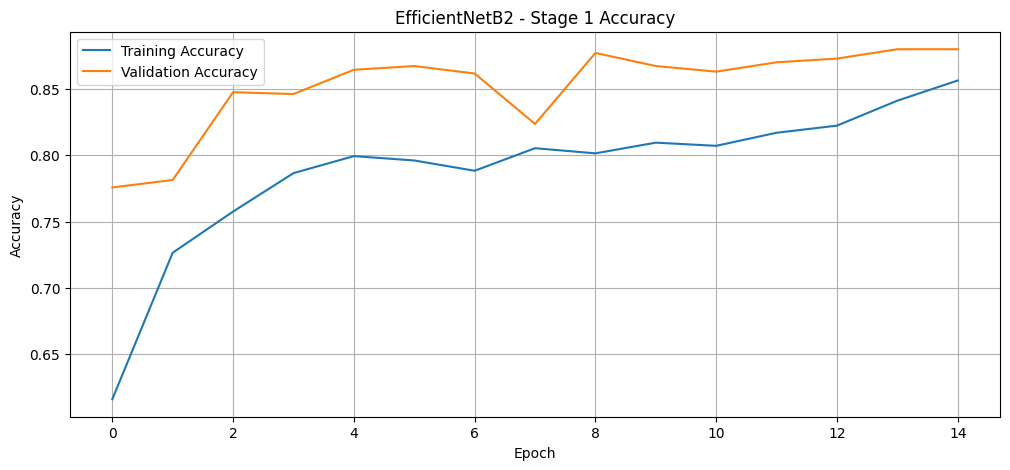

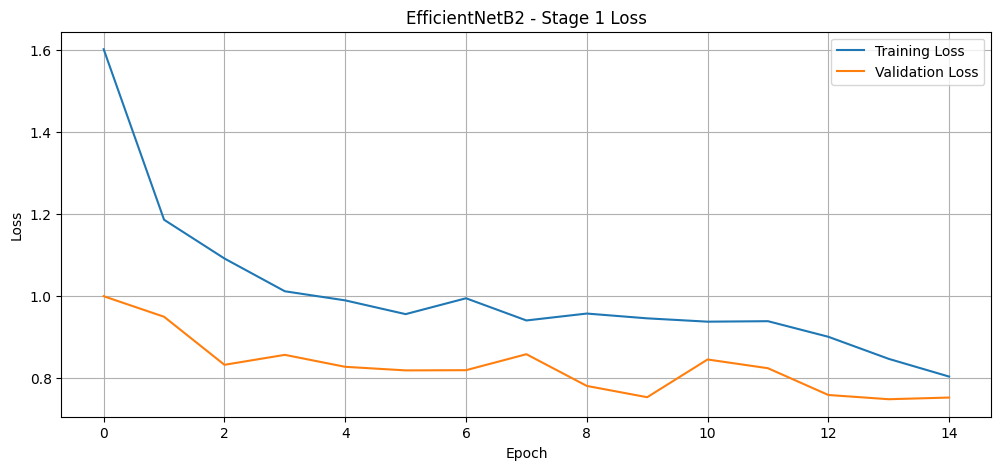

In [63]:
# ============================================================
# TRANSFER LEARNING CURVES
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    transfer_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    transfer_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "EfficientNetB2 - Stage 1 Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()


plt.figure(figsize=(12, 5))

plt.plot(
    transfer_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    transfer_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "EfficientNetB2 - Stage 1 Loss"
)

plt.legend()
plt.grid(True)

plt.show()


In [64]:
# ============================================================
# STAGE 2 - FINE TUNING
# ============================================================

base_model.trainable = True

total_layers = len(base_model.layers)

# Freeze first 70%
fine_tune_from = int(
    total_layers * 0.70
)

for layer in base_model.layers:

    layer.trainable = False


for layer in base_model.layers[
    fine_tune_from:
]:

    layer.trainable = True


trainable_count = sum(
    layer.trainable
    for layer in base_model.layers
)

print(
    "Total backbone layers:",
    total_layers
)

print(
    "Fine-tuning from layer:",
    fine_tune_from
)

print(
    "Trainable backbone layers:",
    trainable_count
)

Total backbone layers: 340
Fine-tuning from layer: 237
Trainable backbone layers: 103


In [65]:
# ============================================================
# RECOMPILE FOR FINE-TUNING
# ============================================================

transfer_model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss=keras.losses.CategoricalCrossentropy(
        label_smoothing=0.05
    ),

    metrics=[
        "accuracy"
    ]
)

print(
    "EfficientNetB2 recompiled "
    "for fine-tuning."
)

EfficientNetB2 recompiled for fine-tuning.


In [66]:
# ============================================================
# FINE-TUNING CALLBACKS
# ============================================================

FINE_TUNE_MODEL_PATH = (
    "/content/drive/MyDrive/"
    "SmartInspect_AI/"
    "SmartInspect_EfficientNetB2_Final.keras"
)

fine_tune_callbacks = [

    keras.callbacks.ModelCheckpoint(

        FINE_TUNE_MODEL_PATH,

        monitor="val_accuracy",

        mode="max",

        save_best_only=True,

        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.25,

        patience=3,

        min_lr=1e-7,

        verbose=1
    ),

    keras.callbacks.EarlyStopping(

        monitor="val_accuracy",

        patience=7,

        mode="max",

        restore_best_weights=True,

        verbose=1
    )
]

In [67]:
# ============================================================
# STAGE 2
# FINE-TUNE EFFICIENTNETB2
# ============================================================

fine_tune_history = transfer_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=FINE_TUNE_EPOCHS,

    class_weight=CLASS_WEIGHTS,

    callbacks=fine_tune_callbacks
)

Epoch 1/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.5422 - loss: 1.7420
Epoch 1: val_accuracy improved from None to 0.84203, saving model to /content/drive/MyDrive/SmartInspect_AI/SmartInspect_EfficientNetB2_Final.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SmartInspect_AI/SmartInspect_EfficientNetB2_Final.keras
210/210 ━━━━━━━━━━━━━━━━━━━━ 75s 218ms/step - accuracy: 0.6141 - loss: 1.5075 - val_accuracy: 0.8420 - val_loss: 0.8670 - learning_rate: 1.0000e-05
Epoch 2/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.7010 - loss: 1.1871
Epoch 2: val_accuracy improved from 0.84203 to 0.84908, saving model to /content/drive/MyDrive/SmartInspect_AI/SmartInspect_EfficientNetB2_Final.keras

Epoch 2: finished saving model to /content/drive/MyDrive/SmartInspect_AI/SmartInspect_EfficientNetB2_Final.keras
210/210 ━━━━━━━━━━━━━━━━━━━━ 77s 196ms/step - accuracy: 0.7259 - loss: 1.1854 - val_accuracy: 0.8491 - val_loss: 0.8592 - learning_rate: 1.0000e-05
E

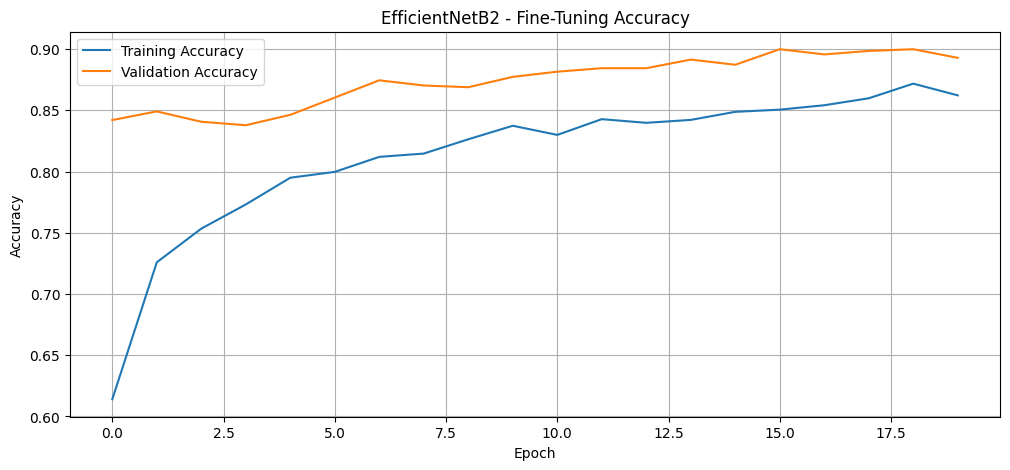

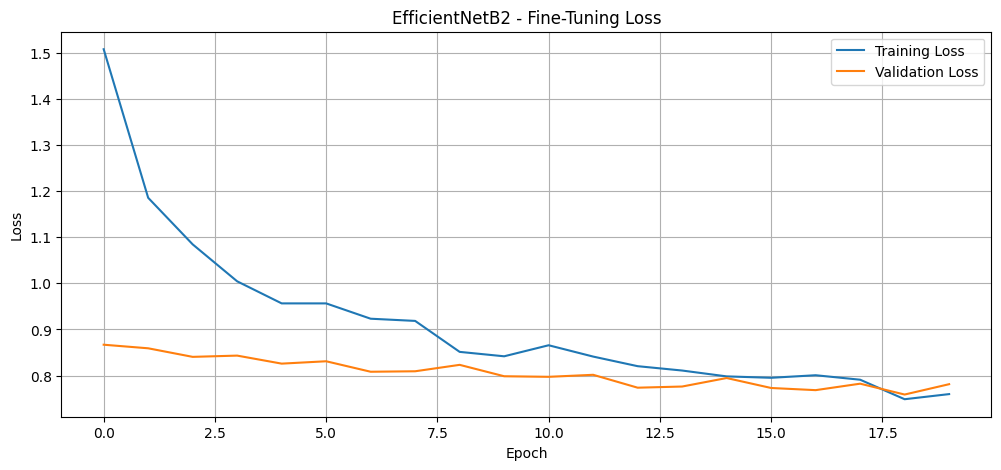

In [68]:
# ============================================================
# FINE-TUNING CURVES
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    fine_tune_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    fine_tune_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "EfficientNetB2 - Fine-Tuning Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()


plt.figure(figsize=(12, 5))

plt.plot(
    fine_tune_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    fine_tune_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "EfficientNetB2 - Fine-Tuning Loss"
)

plt.legend()
plt.grid(True)

plt.show()

In [69]:
# ============================================================
# LOAD BEST MODEL
# ============================================================

if not Path(FINE_TUNE_MODEL_PATH).exists():

    raise FileNotFoundError(
        "Final model file was not found."
    )

best_model = keras.models.load_model(
    FINE_TUNE_MODEL_PATH
)

print(
    "Best SmartInspect AI model loaded."
)

Best SmartInspect AI model loaded.


In [70]:
# ============================================================
# FINAL TEST EVALUATION
# ============================================================

test_loss, test_accuracy = (
    best_model.evaluate(
        test_ds,
        verbose=1
    )
)

print("\n" + "=" * 60)
print("FINAL SMARTINSPECT AI RESULT")
print("=" * 60)

print(
    f"Test Loss     : {test_loss:.4f}"
)

print(
    f"Test Accuracy : {test_accuracy * 100:.2f}%"
)

print("=" * 60)

47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 105ms/step - accuracy: 0.8915 - loss: 0.7220

FINAL SMARTINSPECT AI RESULT
Test Loss     : 0.7220
Test Accuracy : 89.15%


In [71]:
# ============================================================
# GENERATE TEST PREDICTIONS
# ============================================================

y_true = []
y_pred = []
y_probabilities = []

for images, labels in test_ds:

    predictions = best_model.predict(
        images,
        verbose=0
    )

    true_labels = np.argmax(
        labels.numpy(),
        axis=1
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(
        true_labels
    )

    y_pred.extend(
        predicted_labels
    )

    y_probabilities.extend(
        predictions
    )


y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probabilities = np.array(
    y_probabilities
)

print(
    "Predictions generated:",
    len(y_pred)
)

Predictions generated: 737


In [72]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

report = classification_report(

    y_true,

    y_pred,

    target_names=CLASS_NAMES,

    digits=4,

    zero_division=0
)

print(report)

                      precision    recall  f1-score   support

       BSD_defective     0.9268    0.8837    0.9048       129
            BSD_good     0.7879    0.9455    0.8595        55
    bottle_defective     0.8889    0.8000    0.8421        20
         bottle_good     1.0000    1.0000    1.0000        35
     cable_defective     0.8333    0.6897    0.7547        29
          cable_good     0.8958    1.0000    0.9451        43
    carpet_defective     0.7857    0.7857    0.7857        28
         carpet_good     1.0000    1.0000    1.0000        47
      grid_defective     0.7368    0.7778    0.7568        18
           grid_good     0.9348    0.9773    0.9556        44
   leather_defective     0.8148    0.7586    0.7857        29
        leather_good     1.0000    1.0000    1.0000        43
 metal_nut_defective     0.6875    0.5238    0.5946        21
      metal_nut_good     0.8372    0.9730    0.9000        37
toothbrush_defective     0.8333    0.5556    0.6667         9
     to

In [73]:
# ============================================================
# OVERALL METRICS
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("=" * 60)
print("SMARTINSPECT AI METRICS")
print("=" * 60)

print(
    f"Accuracy  : {accuracy * 100:.2f}%"
)

print(
    f"Precision : {precision * 100:.2f}%"
)

print(
    f"Recall    : {recall * 100:.2f}%"
)

print(
    f"F1 Score  : {f1 * 100:.2f}%"
)

print("=" * 60)

SMARTINSPECT AI METRICS
Accuracy  : 89.15%
Precision : 89.15%
Recall    : 89.15%
F1 Score  : 88.84%


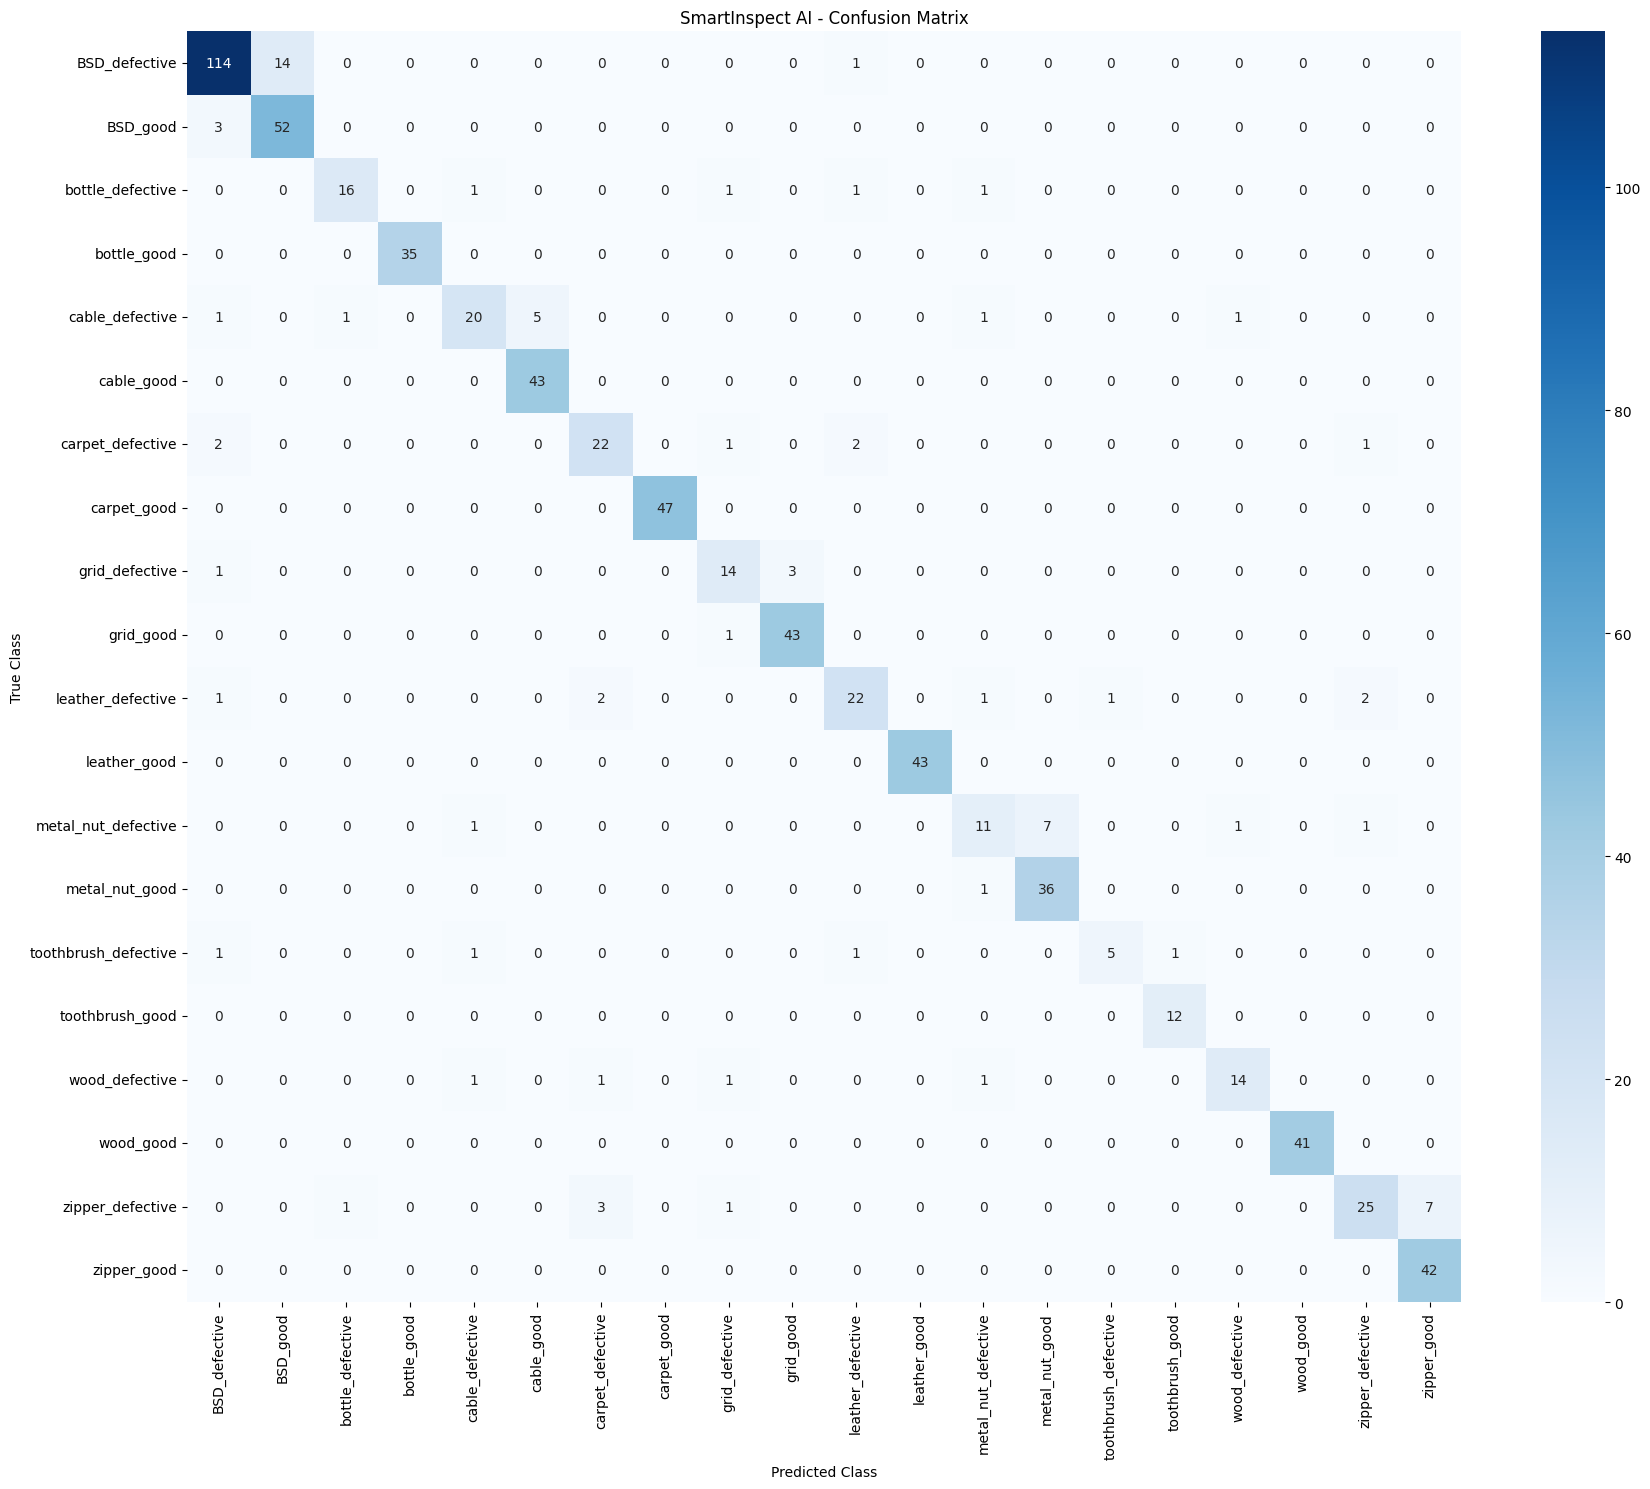

In [74]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(18, 15))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=CLASS_NAMES,

    yticklabels=CLASS_NAMES
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.title(
    "SmartInspect AI - Confusion Matrix"
)

plt.xticks(
    rotation=90
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

plt.show()

In [75]:
# ============================================================
# PER-CLASS ACCURACY
# ============================================================

class_accuracy = []

for i, class_name in enumerate(
    CLASS_NAMES
):

    mask = y_true == i

    if mask.sum() > 0:

        accuracy_i = (
            y_pred[mask] == i
        ).mean()

    else:

        accuracy_i = 0

    class_accuracy.append(
        accuracy_i
    )


class_accuracy_df = pd.DataFrame({

    "Class": CLASS_NAMES,

    "Accuracy": class_accuracy

})

class_accuracy_df[
    "Accuracy (%)"
] = (
    class_accuracy_df["Accuracy"] * 100
)

display(
    class_accuracy_df.sort_values(
        "Accuracy"
    )
)

,Class,Accuracy,Accuracy (%)
12,metal_nut_defective,0.523810,52.380952
14,toothbrush_defective,0.555556,55.555556
18,zipper_defective,0.675676,67.567568
4,cable_defective,0.689655,68.965517
10,leather_defective,0.758621,75.862069
8,grid_defective,0.777778,77.777778
16,wood_defective,0.777778,77.777778
6,carpet_defective,0.785714,78.571429
2,bottle_defective,0.800000,80.000000
0,BSD_defective,0.883721,88.372093


In [76]:
# ============================================================
# BEST / WORST PERFORMING CLASSES
# ============================================================

sorted_accuracy = (
    class_accuracy_df
    .sort_values(
        "Accuracy",
        ascending=False
    )
)

print("TOP 5 CLASSES")
print("=" * 50)

display(
    sorted_accuracy.head(5)
)


print("\nWORST 5 CLASSES")
print("=" * 50)

display(
    sorted_accuracy.tail(5)
)

TOP 5 CLASSES


,Class,Accuracy,Accuracy (%)
3,bottle_good,1.0,100.0
11,leather_good,1.0,100.0
7,carpet_good,1.0,100.0
5,cable_good,1.0,100.0
17,wood_good,1.0,100.0



WORST 5 CLASSES


,Class,Accuracy,Accuracy (%)
10,leather_defective,0.758621,75.862069
4,cable_defective,0.689655,68.965517
18,zipper_defective,0.675676,67.567568
14,toothbrush_defective,0.555556,55.555556
12,metal_nut_defective,0.523810,52.380952


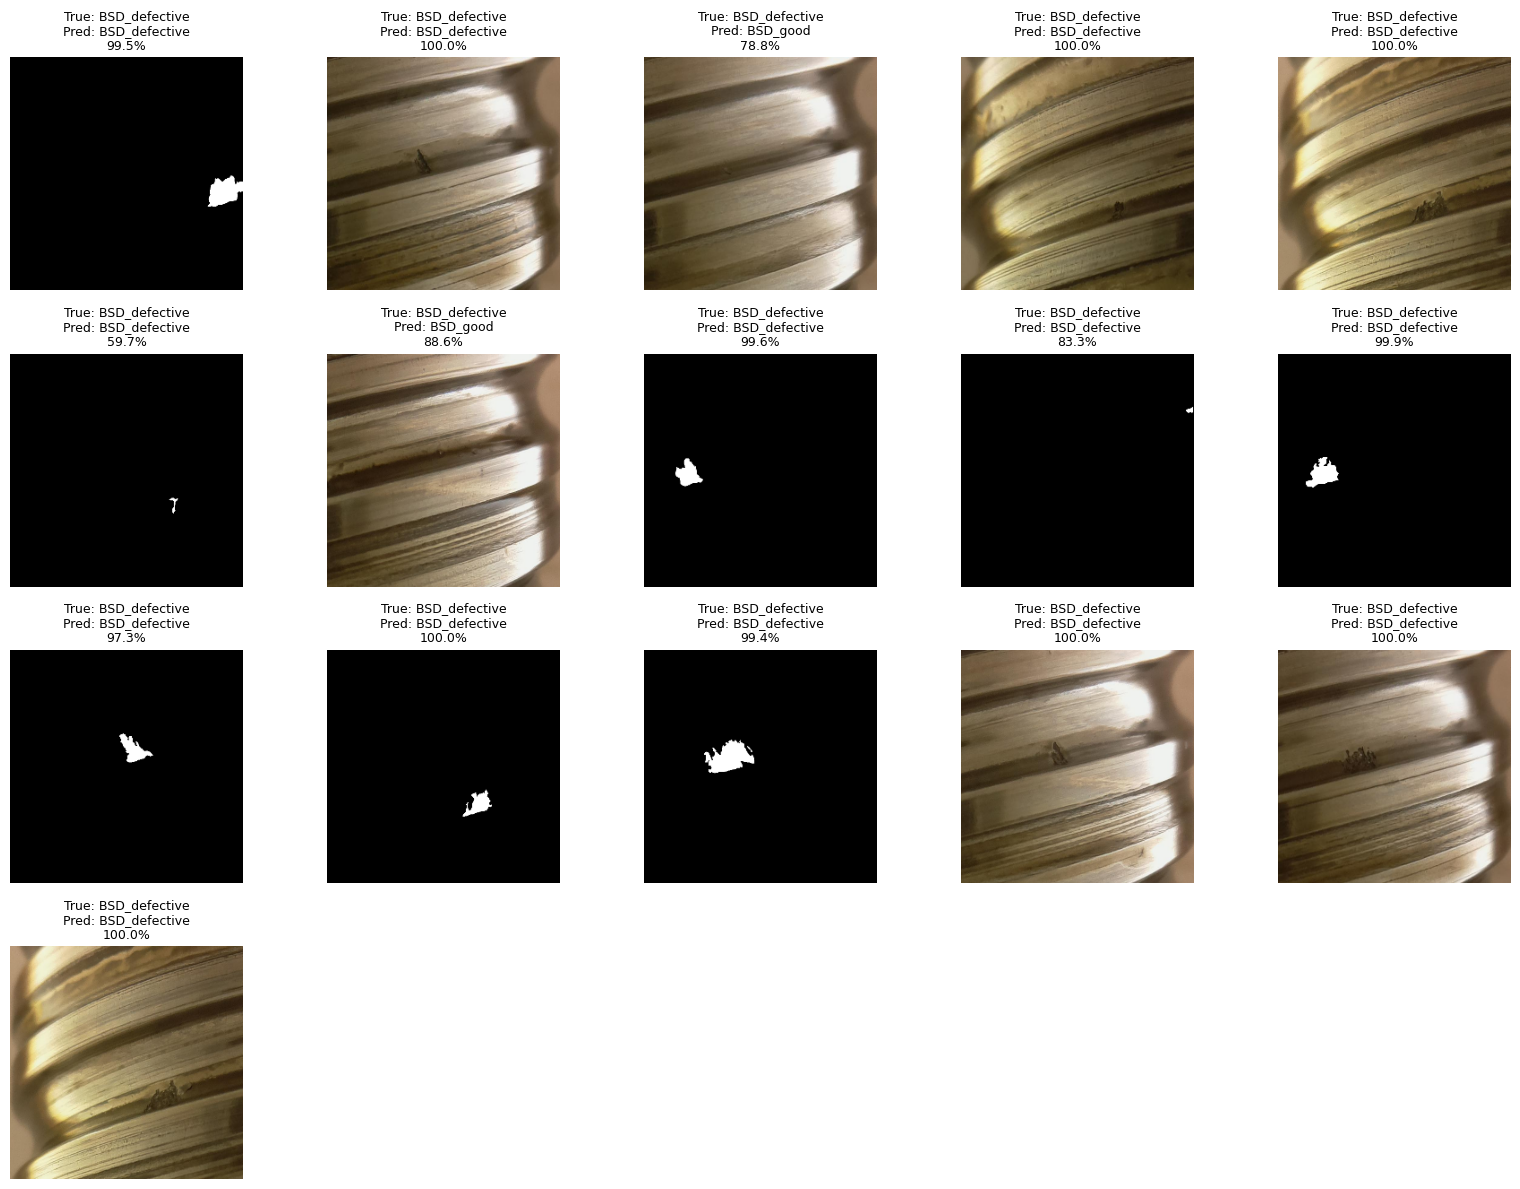

In [77]:
# ============================================================
# SAMPLE PREDICTIONS
# ============================================================

plt.figure(figsize=(16, 12))

for images, labels in test_ds.take(1):

    predictions = best_model.predict(
        images,
        verbose=0
    )

    for i in range(
        min(20, len(images))
    ):

        ax = plt.subplot(4, 5, i + 1)

        image = images[i].numpy()

        true_index = np.argmax(
            labels[i].numpy()
        )

        predicted_index = np.argmax(
            predictions[i]
        )

        confidence = (
            predictions[i][predicted_index]
            * 100
        )

        plt.imshow(
            image.astype("uint8")
        )

        title = (
            f"True: "
            f"{CLASS_NAMES[true_index]}\n"
            f"Pred: "
            f"{CLASS_NAMES[predicted_index]}\n"
            f"{confidence:.1f}%"
        )

        plt.title(
            title,
            fontsize=9
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [78]:
# ============================================================
# WRONG PREDICTIONS
# ============================================================

wrong_indices = np.where(
    y_true != y_pred
)[0]

print(
    "Total wrong predictions:",
    len(wrong_indices)
)

print(
    "Total correct predictions:",
    len(y_true) - len(wrong_indices)
)

print(
    f"Error rate: "
    f"{len(wrong_indices) / len(y_true) * 100:.2f}%"
)

Total wrong predictions: 80
Total correct predictions: 657
Error rate: 10.85%


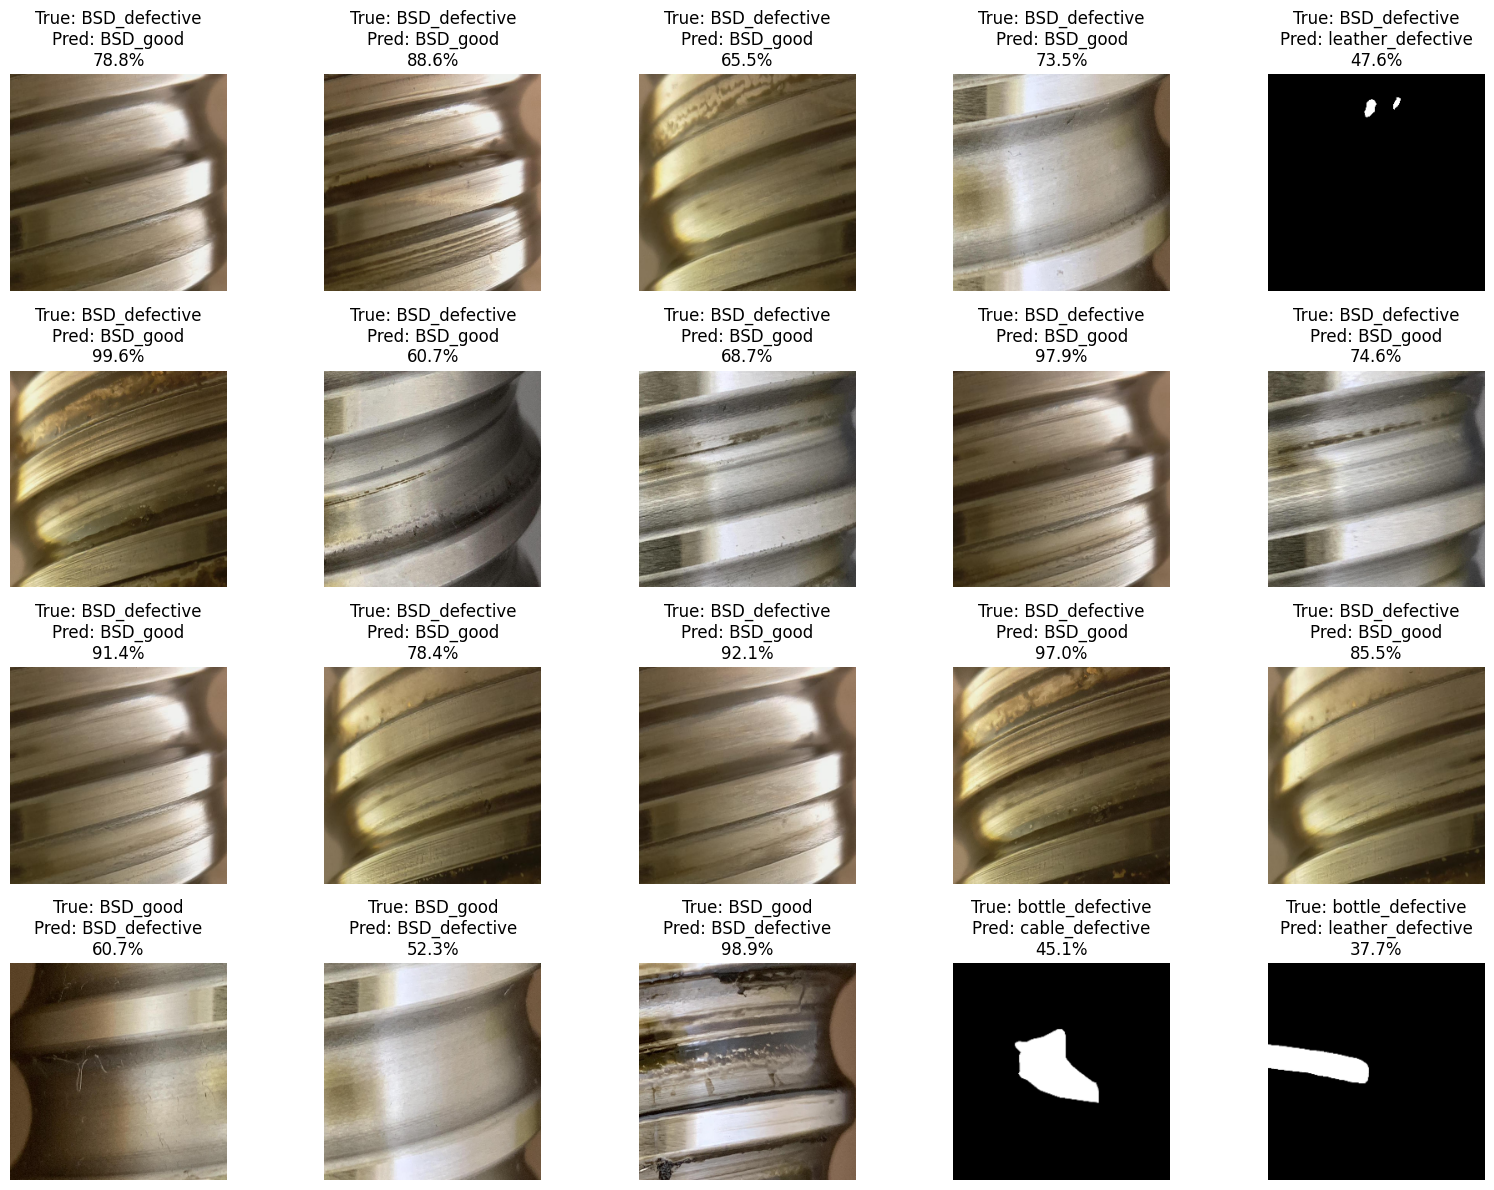

In [79]:
# ============================================================
# VISUALIZE WRONG PREDICTIONS
# ============================================================

wrong_counter = 0

plt.figure(figsize=(16, 12))

for images, labels in test_ds:

    predictions = best_model.predict(
        images,
        verbose=0
    )

    for i in range(len(images)):

        true_index = np.argmax(
            labels[i].numpy()
        )

        predicted_index = np.argmax(
            predictions[i]
        )

        if true_index == predicted_index:
            continue

        ax = plt.subplot(
            4,
            5,
            wrong_counter + 1
        )

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        confidence = (
            predictions[i][predicted_index]
            * 100
        )

        plt.title(
            f"True: {CLASS_NAMES[true_index]}\n"
            f"Pred: {CLASS_NAMES[predicted_index]}\n"
            f"{confidence:.1f}%"
        )

        plt.axis("off")

        wrong_counter += 1

        if wrong_counter >= 20:
            break

    if wrong_counter >= 20:
        break


plt.tight_layout()
plt.show()

In [80]:
# ============================================================
# SAVE CLASS MAPPING
# ============================================================

CLASS_MAPPING_PATH = (
    "/content/drive/MyDrive/"
    "SmartInspect_AI/"
    "class_names.json"
)

with open(
    CLASS_MAPPING_PATH,
    "w"
) as f:

    json.dump(
        CLASS_NAMES,
        f,
        indent=4
    )

print(
    "Class mapping saved to:"
)

print(
    CLASS_MAPPING_PATH
)

Class mapping saved to:
/content/drive/MyDrive/SmartInspect_AI/class_names.json


In [81]:
# ============================================================
# FINAL PROJECT SUMMARY
# ============================================================

print("=" * 70)
print("SMARTINSPECT AI - FINAL PROJECT SUMMARY")
print("=" * 70)

print(
    f"Total dataset images : {total_count}"
)

print(
    f"Training images      : {train_count}"
)

print(
    f"Validation images    : {val_count}"
)

print(
    f"Test images          : {test_count}"
)

print(
    f"Number of classes    : {NUM_CLASSES}"
)

print(
    f"Final test accuracy  : "
    f"{accuracy * 100:.2f}%"
)

print(
    f"Weighted precision   : "
    f"{precision * 100:.2f}%"
)

print(
    f"Weighted recall      : "
    f"{recall * 100:.2f}%"
)

print(
    f"Weighted F1          : "
    f"{f1 * 100:.2f}%"
)

print("=" * 70)

print("\nModel:")
print("EfficientNetB2")

print("\nTraining approach:")
print("1. ImageNet Transfer Learning")
print("2. Classification head training")
print("3. Partial backbone fine-tuning")

print("\nDataset:")
print("10 industrial products")
print("Good + Defective")
print("20 total classes")

print("\nSaved model:")
print(FINE_TUNE_MODEL_PATH)

SMARTINSPECT AI - FINAL PROJECT SUMMARY
Total dataset images : 4791
Training images      : 3345
Validation images    : 709
Test images          : 737
Number of classes    : 20
Final test accuracy  : 89.15%
Weighted precision   : 89.15%
Weighted recall      : 89.15%
Weighted F1          : 88.84%

Model:
EfficientNetB2

Training approach:
1. ImageNet Transfer Learning
2. Classification head training
3. Partial backbone fine-tuning

Dataset:
10 industrial products
Good + Defective
20 total classes

Saved model:
/content/drive/MyDrive/SmartInspect_AI/SmartInspect_EfficientNetB2_Final.keras


In [82]:
# ============================================================
# SMARTINSPECT AI - SINGLE IMAGE PREDICTION
# ============================================================

def predict_image(
    image_path,
    model=best_model
):

    image = Image.open(
        image_path
    ).convert("RGB")

    image = image.resize(
        IMG_SIZE
    )

    image_array = np.array(
        image,
        dtype=np.float32
    )

    image_batch = np.expand_dims(
        image_array,
        axis=0
    )

    probabilities = model.predict(
        image_batch,
        verbose=0
    )[0]

    predicted_index = np.argmax(
        probabilities
    )

    predicted_class = (
        CLASS_NAMES[predicted_index]
    )

    confidence = (
        probabilities[predicted_index]
        * 100
    )

    print("=" * 60)
    print("SMARTINSPECT AI PREDICTION")
    print("=" * 60)

    print(
        "Predicted class:",
        predicted_class
    )

    print(
        f"Confidence: {confidence:.2f}%"
    )

    print("=" * 60)

    plt.figure(figsize=(5, 5))

    plt.imshow(image)

    plt.title(
        f"{predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )

    plt.axis("off")

    plt.show()

    return predicted_class, confidence

Testing image:
/content/SmartInspect_Final/test/BSD_defective/BSD_defective_0125.bmp
SMARTINSPECT AI PREDICTION
Predicted class: BSD_defective
Confidence: 99.94%


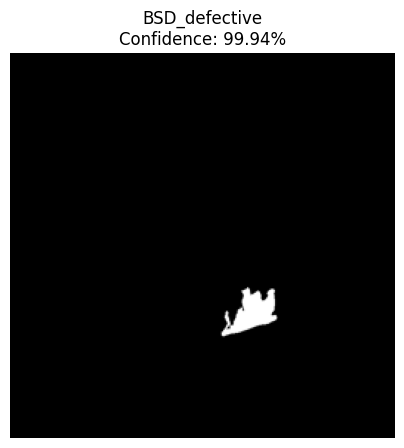

('BSD_defective', np.float32(99.93881))

In [83]:
# ============================================================
# TEST SINGLE IMAGE PREDICTION
# ============================================================

test_images = list(
    TEST_DIR.rglob("*.png")
) + list(
    TEST_DIR.rglob("*.jpg")
) + list(
    TEST_DIR.rglob("*.jpeg")
) + list(
    TEST_DIR.rglob("*.bmp")
)

sample_test_image = random.choice(
    test_images
)

print(
    "Testing image:"
)

print(
    sample_test_image
)

predict_image(
    sample_test_image
)

,Model,Test Accuracy (%)
0,Custom CNN,65.943015
1,EfficientNetB2 Transfer Learning,89.145184


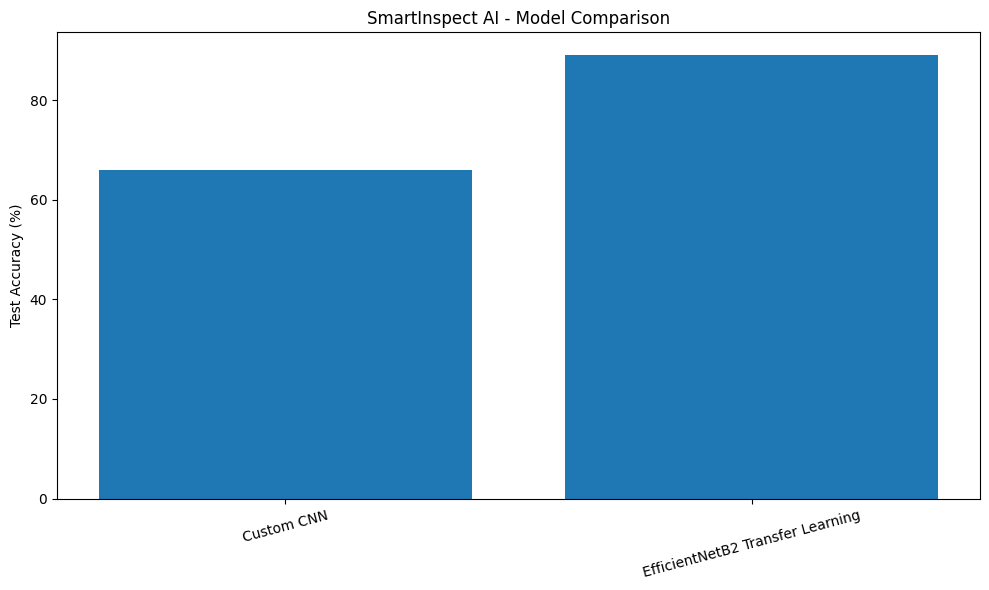

In [84]:
# ============================================================
# MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({

    "Model": [
        "Custom CNN",
        "EfficientNetB2 Transfer Learning"
    ],

    "Test Accuracy (%)": [
        cnn_test_accuracy * 100,
        test_accuracy * 100
    ]
})

display(
    comparison
)

plt.figure(figsize=(10, 6))

plt.bar(
    comparison["Model"],
    comparison["Test Accuracy (%)"]
)

plt.ylabel(
    "Test Accuracy (%)"
)

plt.title(
    "SmartInspect AI - Model Comparison"
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.show()

In [1]:
import sys
import tensorflow as tf

print("Python:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

print("\nTensorFlow:")
print(tf.__version__)

Python:
D:\Downoads\SmartInspect-AI\.venv\Scripts\python.exe

Python version:
3.13.15 (tags/v3.13.15:4061bc4, Aug  5 2026, 13:05:39) [MSC v.1944 64 bit (AMD64)]

TensorFlow:
2.21.0


In [2]:
# ============================================================
# SMARTINSPECT AI - LOCAL PROJECT CONFIGURATION
# ============================================================

from pathlib import Path

PROJECT_DIR = Path(
    r"D:\Downoads\SmartInspect-AI"
)

MODEL_DIR = PROJECT_DIR / "model"

MODEL_PATH = (
    MODEL_DIR /
    "SmartInspect_EfficientNetB2_Final.keras"
)

CLASS_NAMES_PATH = (
    MODEL_DIR /
    "class_names.json"
)

SCREENSHOTS_DIR = PROJECT_DIR / "screenshots"
APP_DIR = PROJECT_DIR / "app"
REPORT_DIR = PROJECT_DIR / "report"

print("Project :", PROJECT_DIR)
print("Model   :", MODEL_PATH)
print("Classes :", CLASS_NAMES_PATH)

print("\nModel exists   :", MODEL_PATH.exists())
print("Classes exist :", CLASS_NAMES_PATH.exists())

Project : D:\Downoads\SmartInspect-AI
Model   : D:\Downoads\SmartInspect-AI\model\SmartInspect_EfficientNetB2_Final.keras
Classes : D:\Downoads\SmartInspect-AI\model\class_names.json

Model exists   : True
Classes exist : True


In [3]:
# ============================================================
# LOAD SMARTINSPECT AI MODEL
# ============================================================

import tensorflow as tf
from tensorflow import keras
import json

print(
    "TensorFlow:",
    tf.__version__
)

model = keras.models.load_model(
    MODEL_PATH
)

with open(
    CLASS_NAMES_PATH,
    "r",
    encoding="utf-8"
) as f:

    CLASS_NAMES_LOCAL = json.load(f)

print("\nModel loaded successfully.")

print(
    "Number of classes:",
    len(CLASS_NAMES_LOCAL)
)

print("\nClasses:")

for i, name in enumerate(
    CLASS_NAMES_LOCAL
):

    print(
        f"{i:2d} -> {name}"
    )

TensorFlow: 2.21.0

Model loaded successfully.
Number of classes: 20

Classes:
 0 -> BSD_defective
 1 -> BSD_good
 2 -> bottle_defective
 3 -> bottle_good
 4 -> cable_defective
 5 -> cable_good
 6 -> carpet_defective
 7 -> carpet_good
 8 -> grid_defective
 9 -> grid_good
10 -> leather_defective
11 -> leather_good
12 -> metal_nut_defective
13 -> metal_nut_good
14 -> toothbrush_defective
15 -> toothbrush_good
16 -> wood_defective
17 -> wood_good
18 -> zipper_defective
19 -> zipper_good


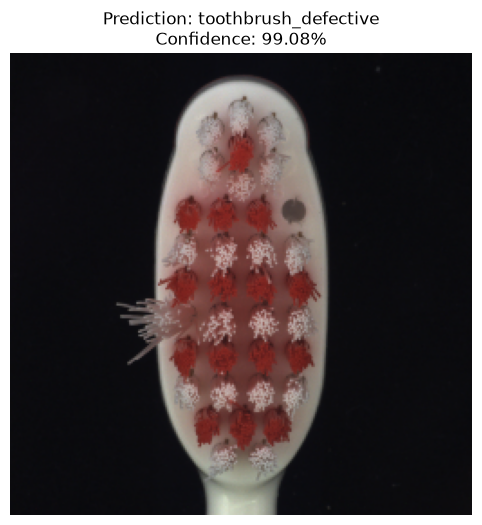

Prediction Results
----------------------------------------
Product    : Toothbrush
Status     : DEFECTIVE
Confidence : 99.08%


In [6]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# CHANGE THIS PATH to any test image
TEST_IMAGE = r"D:\Downoads\SmartInspect-AI\Dataset\toothbrush\bad\test_defective_016.png"

# Load image
image = Image.open(TEST_IMAGE).convert("RGB")

# Resize exactly as used by the model
resized = image.resize((260, 260))

# Convert to NumPy
image_array = np.array(resized, dtype=np.float32)

# Add batch dimension
image_batch = np.expand_dims(image_array, axis=0)

# Prediction
probabilities = model.predict(image_batch, verbose=0)[0]

# Get prediction
predicted_index = np.argmax(probabilities)
predicted_class = CLASS_NAMES_LOCAL[predicted_index]
confidence = probabilities[predicted_index] * 100

# Split product and status
product, status = predicted_class.rsplit("_", 1)

# Display image
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.show()

print("Prediction Results")
print("-" * 40)
print("Product    :", product.replace("_", " ").title())
print("Status     :", status.upper())
print("Confidence :", f"{confidence:.2f}%")

In [7]:
from pathlib import Path

APP_DIR = PROJECT_DIR / "app"
APP_DIR.mkdir(exist_ok=True)

APP_FILE = APP_DIR / "app.py"

app_code = r'''
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
import json
from pathlib import Path

# --------------------------------------------------
# Paths
# --------------------------------------------------

PROJECT_DIR = Path(__file__).resolve().parent.parent

MODEL_PATH = (
    PROJECT_DIR
    / "model"
    / "SmartInspect_EfficientNetB2_Final.keras"
)

CLASS_NAMES_PATH = (
    PROJECT_DIR
    / "model"
    / "class_names.json"
)

IMG_SIZE = (260, 260)


# --------------------------------------------------
# Page Configuration
# --------------------------------------------------

st.set_page_config(
    page_title="SmartInspect AI",
    page_icon="🔍",
    layout="centered"
)


# --------------------------------------------------
# Load Model
# --------------------------------------------------

@st.cache_resource
def load_model():
    return tf.keras.models.load_model(MODEL_PATH)


@st.cache_data
def load_classes():
    with open(CLASS_NAMES_PATH, "r", encoding="utf-8") as f:
        return json.load(f)


model = load_model()
class_names = load_classes()


# --------------------------------------------------
# Application UI
# --------------------------------------------------

st.title("🔍 SmartInspect AI")
st.subheader("Industrial Defect Detection")

st.write(
    "CNN + EfficientNetB2 Transfer Learning"
)

st.divider()


uploaded_file = st.file_uploader(
    "Upload an industrial product image",
    type=["jpg", "jpeg", "png", "bmp"]
)


if uploaded_file is not None:

    image = Image.open(uploaded_file).convert("RGB")

    st.image(
        image,
        caption="Uploaded Product Image",
        use_container_width=True
    )

    if st.button(
        "🔍 Inspect Product",
        type="primary",
        use_container_width=True
    ):

        # Resize image
        resized = image.resize(IMG_SIZE)

        # Convert to NumPy
        image_array = np.array(
            resized,
            dtype=np.float32
        )

        # Add batch dimension
        image_batch = np.expand_dims(
            image_array,
            axis=0
        )

        # Prediction
        probabilities = model.predict(
            image_batch,
            verbose=0
        )[0]

        predicted_index = np.argmax(probabilities)

        predicted_class = class_names[
            predicted_index
        ]

        confidence = (
            probabilities[predicted_index] * 100
        )

        # Separate product and status
        product, status = predicted_class.rsplit(
            "_",
            1
        )

        # --------------------------------------------------
        # Results
        # --------------------------------------------------

        st.divider()

        st.header("Inspection Result")

        col1, col2 = st.columns(2)

        with col1:
            st.metric(
                "Product",
                product.replace(
                    "_",
                    " "
                ).title()
            )

        with col2:
            st.metric(
                "Confidence",
                f"{confidence:.2f}%"
            )

        if status == "defective":

            st.error(
                "⚠️ DEFECTIVE PRODUCT"
            )

        else:

            st.success(
                "✅ GOOD PRODUCT"
            )

        st.write(
            f"**Predicted Class:** `{predicted_class}`"
        )

        # --------------------------------------------------
        # Top 3 Predictions
        # --------------------------------------------------

        st.subheader(
            "Top 3 Predictions"
        )

        top_indices = np.argsort(
            probabilities
        )[::-1][:3]

        for index in top_indices:

            score = (
                probabilities[index] * 100
            )

            st.write(
                f"**{class_names[index]}** — "
                f"{score:.2f}%"
            )

            st.progress(
                float(probabilities[index])
            )


# --------------------------------------------------
# Footer
# --------------------------------------------------

st.divider()

st.caption(
    "SmartInspect AI | "
    "Industrial Defect Detection | "
    "EfficientNetB2 Transfer Learning"
)
'''

APP_FILE.write_text(
    app_code,
    encoding="utf-8"
)

print("Streamlit application created successfully.")
print("Location:")
print(APP_FILE)

print("\nFile exists:", APP_FILE.exists())

Streamlit application created successfully.
Location:
D:\Downoads\SmartInspect-AI\app\app.py

File exists: True


In [8]:
from pathlib import Path

requirements = """streamlit
tensorflow==2.21.0
numpy
pillow
"""

requirements_file = PROJECT_DIR / "requirements.txt"

requirements_file.write_text(
    requirements,
    encoding="utf-8"
)

print("Created:")
print(requirements_file)

print("\nContents:")
print(requirements_file.read_text())

Created:
D:\Downoads\SmartInspect-AI\requirements.txt

Contents:
streamlit
tensorflow==2.21.0
numpy
pillow

